# 1.Category Contribution and Reviews Distribution

/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_50553/1277736165.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


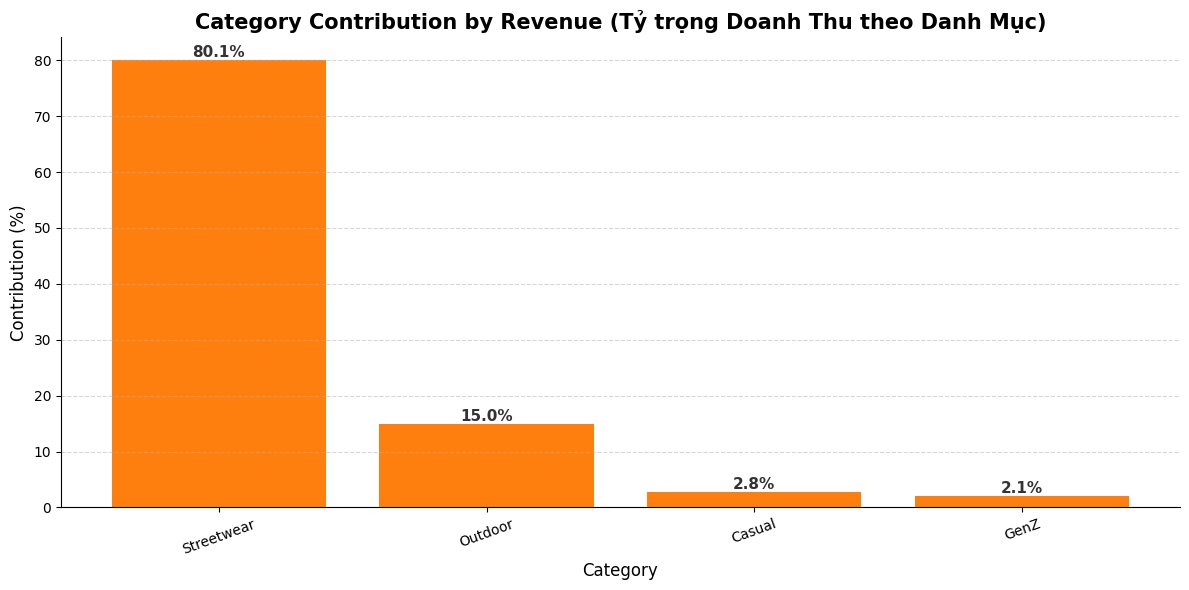

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
products = pd.read_csv(BASE_DATA + 'products.csv')
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')

# 2. Merge dữ liệu để lấy category cho từng item dựa vào product_id
order_items_merged = order_items.merge(products[['product_id', 'category']], on='product_id', how='inner')

# 3. Tính doanh thu (Revenue) cho mỗi sản phẩm bán ra
order_items_merged['revenue'] = (order_items_merged['quantity'] * order_items_merged['unit_price']) - order_items_merged['discount_amount'].fillna(0)

# 4. Gom nhóm tính tổng doanh thu theo Category 
category_revenue = order_items_merged.groupby('category')['revenue'].sum().sort_values(ascending=False)

# 5. Phân tích tỷ trọng phần trăm (Contribution)
total_revenue = category_revenue.sum()
category_percentage = (category_revenue / total_revenue) * 100

# ==========================================
# Vẽ biểu đồ Bar Chart Percentage
# ==========================================
plt.figure(figsize=(12, 6))
bars = plt.bar(category_percentage.index, category_percentage.values, color='#ff7f0e')

# Thêm số % lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#333333')

plt.title('Category Contribution by Revenue (Tỷ trọng Doanh Thu theo Danh Mục)', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Contribution (%)', fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Bỏ viền thừa của biểu đồ cho thiết kế thanh thoát hơn
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


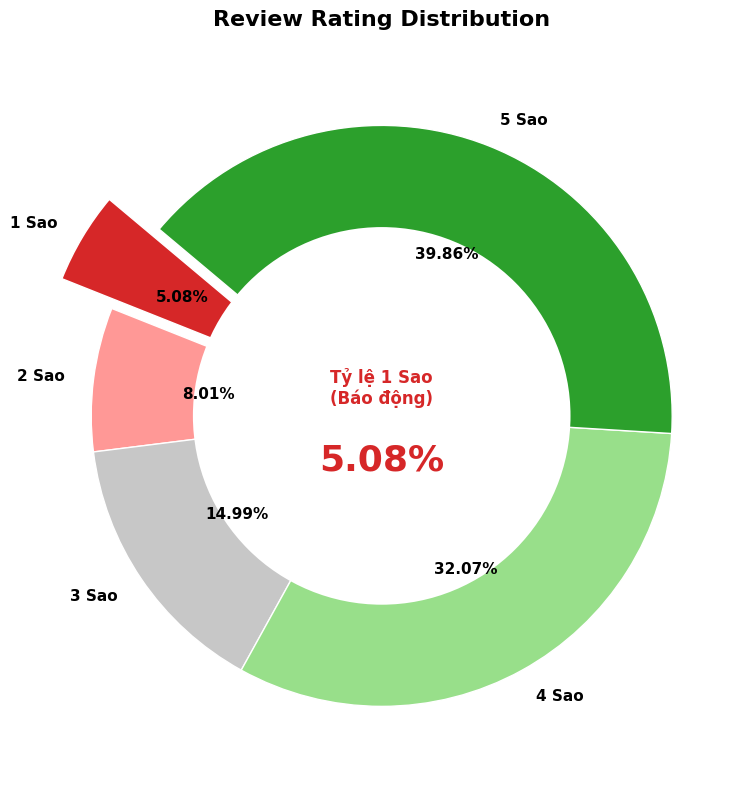

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu đánh giá
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv')

# 2. Đếm số lượng theo giá trị rating (từ 1 đến 5 sao)
rating_counts = reviews['rating'].value_counts()
total_reviews = len(reviews)

# Chuẩn hóa thứ tự index từ 1 đến 5 sao (với mapping string)
mapping = {1: '1 Sao', 2: '2 Sao', 3: '3 Sao', 4: '4 Sao', 5: '5 Sao'}
rating_counts.index = rating_counts.index.map(mapping)
rating_counts = rating_counts.reindex(['1 Sao', '2 Sao', '3 Sao', '4 Sao', '5 Sao']).fillna(0)

# 3. Tính % tỷ lệ phân bổ của các sao
percentage = rating_counts / total_reviews

# ==========================================
# Vẽ biểu đồ Donut Chart (Highlight 1 Sao bị vỡ ra khỏi bánh)
# ==========================================
# Set màu: Trắng/đỏ để nhấn mạnh sự tiêu cực của 1 sao, các review cao dần thì xanh lá
colors = ['#d62728', '#ff9896', '#c7c7c7', '#98df8a', '#2ca02c'] 
explode = (0.2, 0, 0, 0, 0)  # Tách lát cắt 1 sao (index 0) ra khỏi bánh

plt.figure(figsize=(8, 8))
plt.pie(percentage, explode=explode, labels=percentage.index, colors=colors, 
        autopct='%1.2f%%', startangle=140, textprops={'fontsize': 11, 'weight': 'bold'},
        wedgeprops=dict(edgecolor='w'))

# Thêm vòng tròn trắng ở giữa để tạo thành Donut chart đương đại
centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# In số liệu đúc kết của phần 1 Sao ngay ở giữa tâm chart!
one_star_pct = percentage.get('1 Sao', 0)
plt.text(0, 0.1, 'Tỷ lệ 1 Sao\n(Báo động)', ha='center', va='center', fontsize=12, color='#d62728', fontweight='bold')
plt.text(0, -0.15, f'{one_star_pct:.2%}', ha='center', va='center', fontsize=26, color='#d62728', fontweight='bold')

plt.title('Review Rating Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# 2. Sentiment Analysis

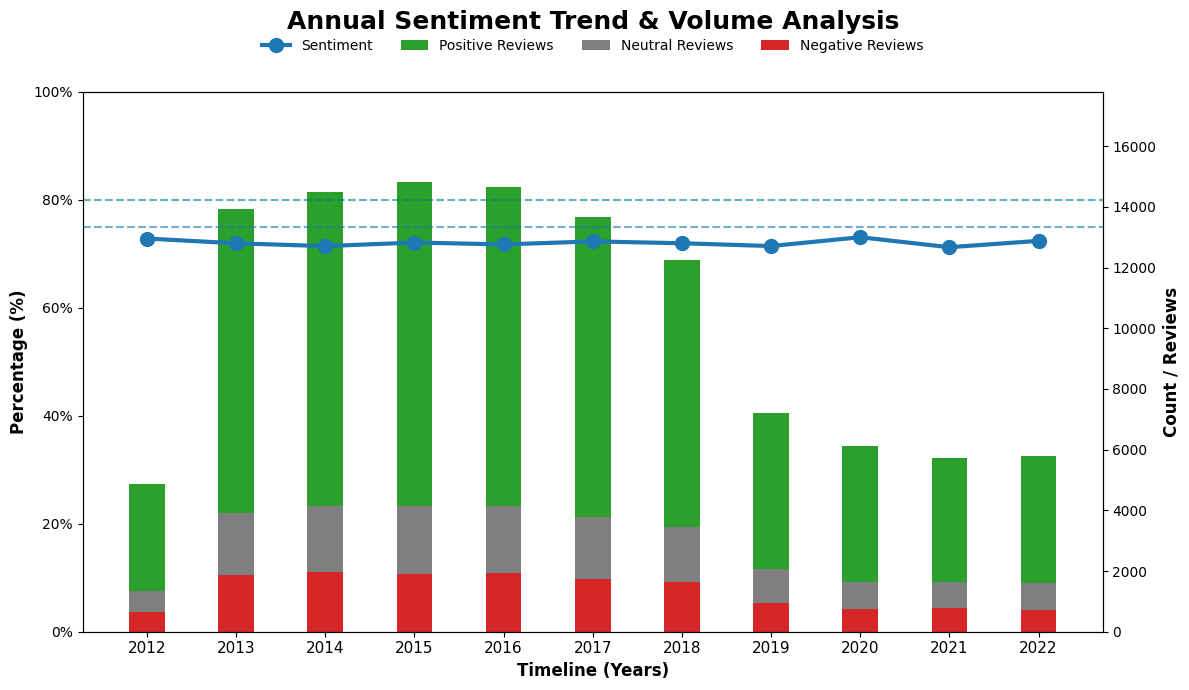

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# 1. Đọc dữ liệu (Bỏ lọc năm 2022 để lấy toàn bộ các năm có trong data)
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv', parse_dates=['review_date'])

# 2. Phân loại Cảm xúc (Sentiment Rating)
def classify_rating(r):
    if r in [1, 2]: return 'Negative'
    elif r == 3: return 'Neutral'
    else: return 'Positive'

reviews['sentiment'] = reviews['rating'].apply(classify_rating)

reviews['Year'] = reviews['review_date'].dt.year

# 3. Gom nhóm theo Năm
pivot = reviews.groupby(['Year', 'sentiment']).size().unstack(fill_value=0)

# Đảm bảo có đủ 3 cột
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in pivot.columns:
        pivot[col] = 0

pivot['Total'] = pivot['Negative'] + pivot['Neutral'] + pivot['Positive']
pivot['Sentiment_Pct'] = (pivot['Positive'] / pivot['Total']) * 100

# Chuẩn bị dữ liệu vẽ
x_labels = pivot.index.astype(str).tolist()
pos = pivot['Positive'].values
neu = pivot['Neutral'].values
neg = pivot['Negative'].values
sentiment_line = pivot['Sentiment_Pct'].values

# ==========================================
# VẼ BIỂU ĐỒ KÉP (DUAL AXIS CHART)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 7))

# Trục phụ ax2 (Cột chồng - Secondary Right Y-Axis)
ax2 = ax1.twinx()
width = 0.4 # Giảm độ rộng cột vì số lượng năm thường ít hơn số tháng
x_pos = np.arange(len(x_labels))

# Vẽ cột chồng
p_neg = ax2.bar(x_pos, neg, width, label='Negative Reviews', color='#d62728', zorder=2)
p_neu = ax2.bar(x_pos, neu, width, bottom=neg, label='Neutral Reviews', color='#7f7f7f', zorder=2)
p_pos = ax2.bar(x_pos, pos, width, bottom=neg+neu, label='Positive Reviews', color='#2ca02c', zorder=2)

ax2.set_ylabel('Count / Reviews', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(pivot['Total']) * 1.2) 

# Trục chính ax1 (Line - Primary Left Y-Axis)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

p_line, = ax1.plot(x_pos, sentiment_line, color='#1f77b4', marker='o', markersize=10, 
                   linewidth=3, label='Sentiment', zorder=3)

ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Đường Tham Chiếu
ax1.axhline(75, color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
ax1.axhline(80, color='#008080', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

# Format Trục hoành theo Năm
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, fontsize=11)
ax1.set_xlabel('Timeline (Years)', fontsize=12, fontweight='bold')

# Legend & Summary
handles = [p_line, p_pos, p_neu, p_neg]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)

plt.title('Annual Sentiment Trend & Volume Analysis', pad=45, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
display(pivot)

sentiment,Negative,Neutral,Positive,Total,Sentiment_Pct
Year,,,,,
2012,650,678,3551,4879,72.781308
2013,1859,2059,10024,13942,71.897863
2014,1974,2174,10347,14495,71.383236
2015,1901,2246,10687,14834,72.043953
2016,1928,2220,10505,14653,71.691804
2017,1736,2060,9883,13679,72.249433
2018,1629,1809,8801,12239,71.909470
2019,948,1109,5134,7191,71.394799
2020,741,906,4459,6106,73.026531


/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_50553/1944141464.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


Đã ghi dữ liệu nhóm 'Stars (Sản phẩm Hạt nhân - Đẩy mạnh)' vào file: product_stars_hat_nhan.txt
Đã ghi dữ liệu nhóm 'Hidden Gems (Kim cương ẩn - Cần Marketing)' vào file: product_hidden_gems_kim_cuong.txt
Đã ghi dữ liệu nhóm 'Cash Cows (Sản phẩm Mồi/Vắt sữa)' vào file: product_cash_cows_v_sua.txt
Đã ghi dữ liệu nhóm 'Dogs (Sản phẩm Lỗi - Xem xét loại bỏ)' vào file: product_dogs_loi.txt


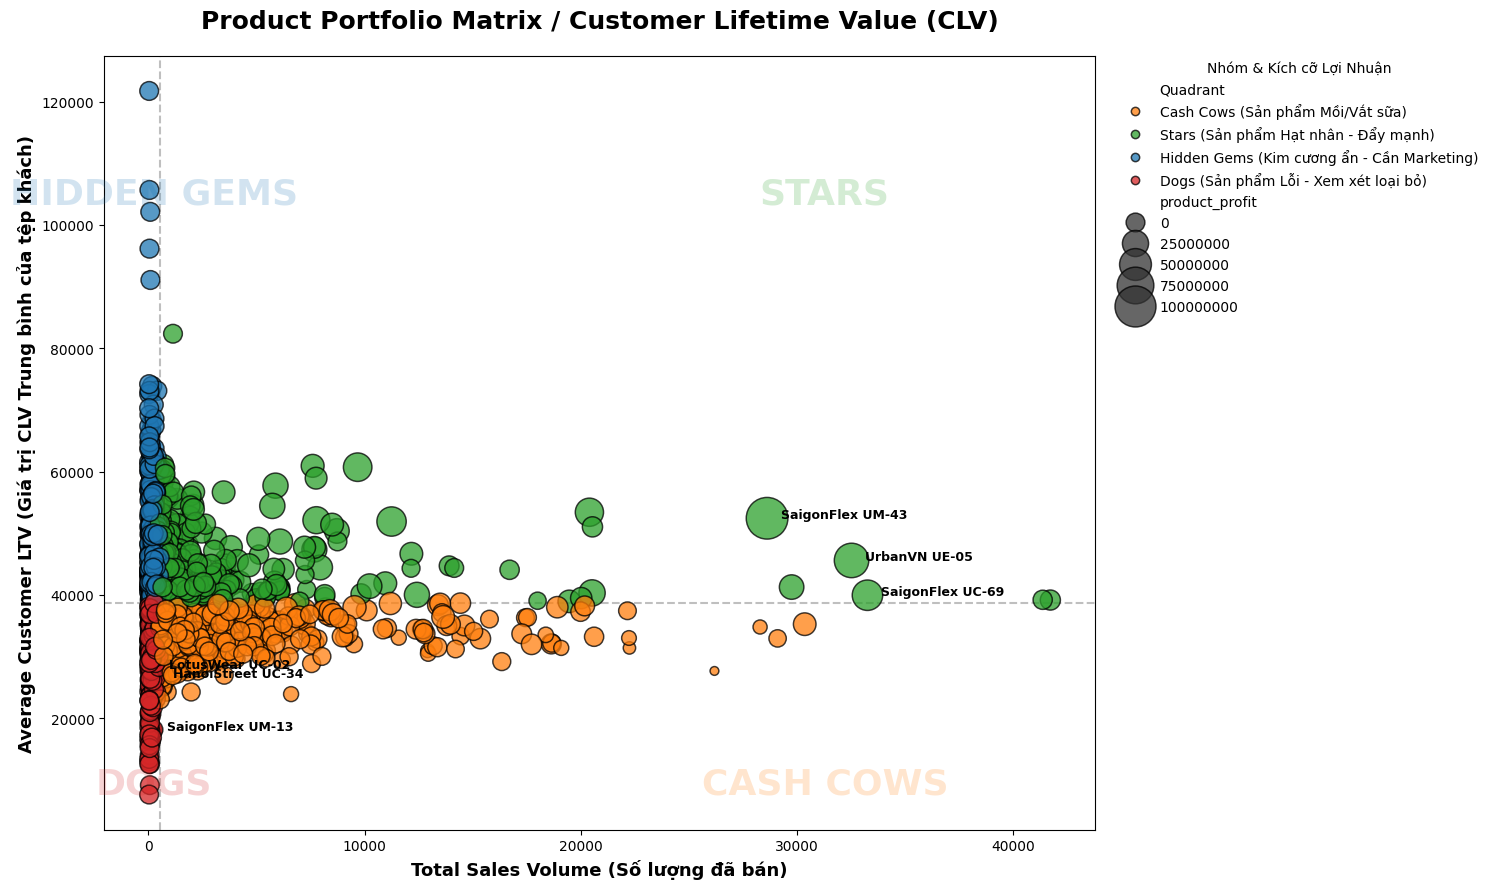

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Đọc dữ liệu
BASE_DATA = "data/"
orders = pd.read_csv(BASE_DATA + 'orders.csv')
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')
products = pd.read_csv(BASE_DATA + 'products.csv')

# Lọc bỏ các đơn bị hủy
orders = orders[orders['order_status'] != 'cancelled']

# 2. Hợp nhất bảng (Merge)
df = order_items.merge(orders[['order_id', 'customer_id']], on='order_id', how='inner')
df = df.merge(products[['product_id', 'product_name', 'cogs', 'category']], on='product_id', how='inner')

# 3. Tính Lợi nhuận và Customer LTV
df['profit'] = (df['quantity'] * df['unit_price']) - df['discount_amount'].fillna(0) - (df['quantity'] * df['cogs'])
customer_ltv = df.groupby('customer_id')['profit'].sum().reset_index()
customer_ltv.rename(columns={'profit': 'customer_LTV'}, inplace=True)

# 4. Ánh xạ LTV ngược về Sản Phẩm
df = df.merge(customer_ltv, on='customer_id', how='left')

# 5. Phân tích Cấp độ Sản phẩm
product_stats = df.groupby(['product_id', 'product_name', 'category']).agg(
    total_sales_volume=('quantity', 'sum'),
    avg_buyer_LTV=('customer_LTV', 'mean'),
    product_profit=('profit', 'sum')
).reset_index()

# Lọc volume để tránh nhiễu
product_stats = product_stats[product_stats['total_sales_volume'] > 30]

# 6. Phân bổ 4 Góc Ma Trận
med_volume = product_stats['total_sales_volume'].median()
med_ltv = product_stats['avg_buyer_LTV'].median()

# Định nghĩa các nhãn đúng như yêu cầu
STARS = 'Stars (Sản phẩm Hạt nhân - Đẩy mạnh)'
GEMS  = 'Hidden Gems (Kim cương ẩn - Cần Marketing)'
COWS  = 'Cash Cows (Sản phẩm Mồi/Vắt sữa)'
DOGS  = 'Dogs (Sản phẩm Lỗi - Xem xét loại bỏ)'

def classify_product(row):
    if row['total_sales_volume'] >= med_volume and row['avg_buyer_LTV'] >= med_ltv:
        return STARS
    elif row['total_sales_volume'] < med_volume and row['avg_buyer_LTV'] >= med_ltv:
        return GEMS
    elif row['total_sales_volume'] >= med_volume and row['avg_buyer_LTV'] < med_ltv:
        return COWS
    else:
        return DOGS

product_stats['Quadrant'] = product_stats.apply(classify_product, axis=1)

# ==========================================
# XUẤT RA 4 FILE RIÊNG BIỆT
# ==========================================
# Map tên nhóm với tên file (loại bỏ ký tự đặc biệt để đặt tên file an toàn)
file_mapping = {
    STARS: "product_stars_hat_nhan.txt",
    GEMS:  "product_hidden_gems_kim_cuong.txt",
    COWS:  "product_cash_cows_v_sua.txt",
    DOGS:  "product_dogs_loi.txt"
}

for quad_label, file_name in file_mapping.items():
    subset = product_stats[product_stats['Quadrant'] == quad_label].sort_values(by='product_profit', ascending=False)
    
    with open(file_name, 'w', encoding='utf-8') as f:
        f.write(f"--- DANH SÁCH {quad_label.upper()} ---\n\n")
        if subset.empty:
            f.write("Không có sản phẩm nào thuộc nhóm này.\n")
        else:
            for _, row in subset.iterrows():
                f.write(f" - {row['product_name']} | Tệp LTV: ${row['avg_buyer_LTV']:,.0f} | Bán ra: {row['total_sales_volume']:,} cái | Lợi nhuận: ${row['product_profit']:,.0f}\n")
    print(f"Đã ghi dữ liệu nhóm '{quad_label}' vào file: {file_name}")

# TRỰC QUAN HÓA MATRIX (BUBBLE SCATTER PLOT)
# ==========================================
plt.figure(figsize=(15, 9))
scatter = sns.scatterplot(
    data=product_stats, 
    x='total_sales_volume', 
    y='avg_buyer_LTV', 
    hue='Quadrant', 
    palette={'Stars (Sản phẩm Hạt nhân - Đẩy mạnh)': '#2ca02c', 
             'Hidden Gems (Kim cương ẩn - Cần Marketing)': '#1f77b4', 
             'Cash Cows (Sản phẩm Mồi/Vắt sữa)': '#ff7f0e', 
             'Dogs (Sản phẩm Lỗi - Xem xét loại bỏ)': '#d62728'},
    size='product_profit', sizes=(40, 900), alpha=0.75, edgecolor='black', zorder=2
)

# Hai đường Line tham chiếu xé biểu đồ làm 4 mặt phẳng
plt.axvline(med_volume, color='gray', linestyle='--', alpha=0.5, zorder=1)
plt.axhline(med_ltv, color='gray', linestyle='--', alpha=0.5, zorder=1)

# Gắn nhãn tên sản phẩm vào Top 3 Star và Top 3 Dog để nhìn là biết luôn
top_stars = product_stats[product_stats['Quadrant'] == 'Stars (Sản phẩm Hạt nhân - Đẩy mạnh)'].nlargest(3, 'product_profit')
top_dogs = product_stats[product_stats['Quadrant'] == 'Dogs (Sản phẩm Lỗi - Xem xét loại bỏ)'].nsmallest(3, 'product_profit')

for _, row in pd.concat([top_stars, top_dogs]).iterrows():
    plt.text(row['total_sales_volume'] + product_stats['total_sales_volume'].max()*0.015, 
             row['avg_buyer_LTV'], row['product_name'], fontsize=9, fontweight='bold', zorder=3)

# Text mờ Highlight 4 phân khu
x_max, y_max = product_stats['total_sales_volume'].max(), product_stats['avg_buyer_LTV'].max()
plt.text(x_max*0.75, y_max*0.85, 'STARS', fontsize=26, color='#2ca02c', alpha=0.2, weight='bold', ha='center')
plt.text(med_volume/2, y_max*0.85, 'HIDDEN GEMS', fontsize=26, color='#1f77b4', alpha=0.2, weight='bold', ha='center')
plt.text(x_max*0.75, med_ltv*0.2, 'CASH COWS', fontsize=26, color='#ff7f0e', alpha=0.2, weight='bold', ha='center')
plt.text(med_volume/2, med_ltv*0.2, 'DOGS', fontsize=26, color='#d62728', alpha=0.2, weight='bold', ha='center')

# Labels and Styling
plt.title('Product Portfolio Matrix / Customer Lifetime Value (CLV)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Sales Volume (Số lượng đã bán)', fontsize=13, fontweight='bold')
plt.ylabel('Average Customer LTV (Giá trị CLV Trung bình của tệp khách)', fontsize=13, fontweight='bold')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, borderaxespad=0., title="Nhóm & Kích cỡ Lợi Nhuận")
plt.tight_layout()
plt.show()
